# Transformer Architecture Playground — 6 Hands-On Projects

Using pretrained models from Hugging Face to try out the concepts from:
- Tokenization & Attention Fundamentals
- Encoder-Only (BERT)
- Decoder-Only (GPT-2)
- Encoder-Decoder (T5)

Run the setup cell below first to make sure the libraries are ready.

In [1]:
import torch
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

torch: 2.11.0+cu128
CUDA available: True


---
## 1) Comparing Tokenizers (BPE vs WordPiece vs Unigram)

Goal: see hands-on how each algorithm splits the same sentence differently —
GPT-2 (BPE), BERT (WordPiece), T5 (Unigram/SentencePiece).

In [2]:
from transformers import AutoTokenizer

tokenizers = {
    "GPT-2 (BPE)": AutoTokenizer.from_pretrained("gpt2"),
    "BERT (WordPiece)": AutoTokenizer.from_pretrained("bert-base-uncased"),
    "T5 (Unigram/SentencePiece)": AutoTokenizer.from_pretrained("t5-small"),
}

sentences = [
    "unhappiness is temporary",
    "SolidGoldMagikarp",
    "transformers are unbelievably powerful",
]

for sentence in sentences:
    print(f"\nSentence: {sentence!r}")
    for name, tok in tokenizers.items():
        tokens = tok.tokenize(sentence)
        print(f"  {name:28s} -> {len(tokens):2d} tokens: {tokens}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]


Sentence: 'unhappiness is temporary'
  GPT-2 (BPE)                  ->  5 tokens: ['un', 'h', 'appiness', 'Ġis', 'Ġtemporary']
  BERT (WordPiece)             ->  6 tokens: ['un', '##ha', '##pp', '##iness', 'is', 'temporary']
  T5 (Unigram/SentencePiece)   ->  6 tokens: ['▁un', 'h', 'app', 'iness', '▁is', '▁temporary']

Sentence: 'SolidGoldMagikarp'
  GPT-2 (BPE)                  ->  2 tokens: ['Solid', 'GoldMagikarp']
  BERT (WordPiece)             ->  6 tokens: ['solid', '##gold', '##ma', '##gi', '##kar', '##p']
  T5 (Unigram/SentencePiece)   ->  6 tokens: ['▁Solid', 'Gold', 'Mag', 'i', 'kar', 'p']

Sentence: 'transformers are unbelievably powerful'
  GPT-2 (BPE)                  ->  5 tokens: ['transform', 'ers', 'Ġare', 'Ġunbelievably', 'Ġpowerful']
  BERT (WordPiece)             ->  8 tokens: ['transformers', 'are', 'un', '##bel', '##ie', '##va', '##bly', 'powerful']
  T5 (Unigram/SentencePiece)   ->  8 tokens: ['▁transformer', 's', '▁are', '▁unbe', 'lie', 'v', 'ably', '▁powerful'

**Try it yourself:** change the sentences above — add rare words, names, numbers,
or words in a different language, and see which tokenizer splits them into more
pieces and which keeps them as a single token.

---
## 2) Visualizing Attention Weights (BERT vs GPT-2)

Goal: see with your own eyes the difference between bidirectional attention
(BERT) and causal attention (GPT-2) that we covered in theory.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


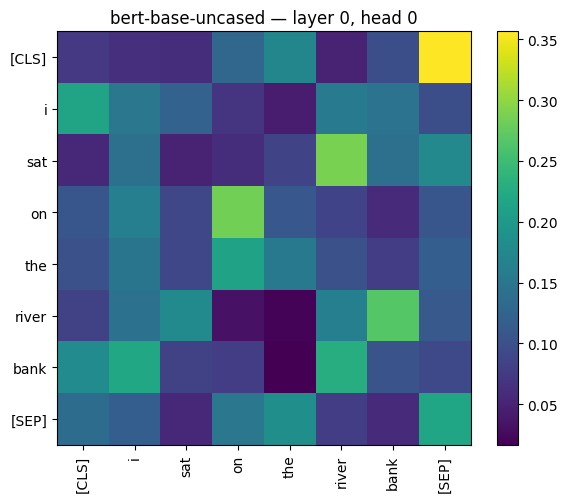

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

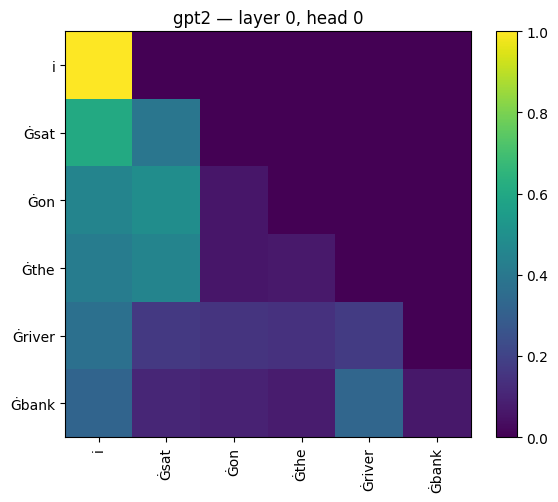

In [4]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel


def plot_attention(model_name, sentence, layer=0, head=0):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, output_attentions=True)
    model.eval()

    inputs = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    # outputs.attentions: tuple of (num_layers) tensors, each [batch, heads, seq, seq]
    attn = outputs.attentions[layer][0, head].numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    plt.figure(figsize=(6, 5))
    plt.imshow(attn, cmap="viridis")
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.title(f"{model_name} — layer {layer}, head {head}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


sentence = "i sat on the river bank"

# Encoder-only: fully dense attention (bidirectional) — every token sees every token
plot_attention("bert-base-uncased", sentence, layer=0, head=0)

# Decoder-only: triangular attention (causal) — every token only sees the ones before it
plot_attention("gpt2", sentence, layer=0, head=0)

**Try it yourself:** change `layer` and `head` to different values (BERT-base has
12 layers and 12 heads) and see how each head focuses on something different
(they won't all look the same).

---
## 3) Masked Language Modeling (MLM) Playground

Goal: see how BERT uses bidirectional context (both sides of the masked word)
to guess the hidden token.

In [5]:
from transformers import pipeline

fill_mask = pipeline("fill-mask", model="bert-base-uncased")

sentences = [
    "The capital of France is [MASK].",
    "I forgot to bring my [MASK] to the exam.",
    "The weather today is very [MASK].",
]

for sentence in sentences:
    print(f"\n{sentence}")
    for pred in fill_mask(sentence, top_k=5):
        print(f"  {pred['token_str']:15s} score={pred['score']:.4f}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



The capital of France is [MASK].
  paris           score=0.4168
  lille           score=0.0714
  lyon            score=0.0634
  marseille       score=0.0444
  tours           score=0.0303

I forgot to bring my [MASK] to the exam.
  phone           score=0.0895
  tablet          score=0.0545
  homework        score=0.0371
  head            score=0.0363
  laptop          score=0.0350

The weather today is very [MASK].
  warm            score=0.2212
  good            score=0.1151
  hot             score=0.0984
  pleasant        score=0.0665
  cold            score=0.0662


---
## 4) Decoding Strategies (Greedy / Temperature / Top-k / Top-p)

Goal: pull the raw logits out of GPT-2 yourself and implement each decoding
strategy manually, instead of just calling `model.generate()` — so you feel
the actual difference between each one.

In [6]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")
model.eval()


def generate(prompt, strategy="greedy", max_new_tokens=30, temperature=1.0, k=10, p=0.9):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids

    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(input_ids).logits[:, -1, :]  # logits for the last token only

        if strategy == "greedy":
            next_token = torch.argmax(logits, dim=-1, keepdim=True)

        elif strategy == "temperature":
            probs = F.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

        elif strategy == "top_k":
            top_k_logits, top_k_indices = torch.topk(logits, k)
            probs = F.softmax(top_k_logits, dim=-1)
            sampled = torch.multinomial(probs, num_samples=1)
            next_token = top_k_indices.gather(-1, sampled)

        elif strategy == "top_p":
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            sorted_probs = F.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
            cutoff = (cumulative_probs > p).float().argmax(dim=-1).item() + 1
            top_p_logits = sorted_logits[:, :cutoff]
            top_p_indices = sorted_indices[:, :cutoff]
            probs = F.softmax(top_p_logits, dim=-1)
            sampled = torch.multinomial(probs, num_samples=1)
            next_token = top_p_indices.gather(-1, sampled)

        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        input_ids = torch.cat([input_ids, next_token], dim=-1)

    return tokenizer.decode(input_ids[0])


prompt = "The future of artificial intelligence is"

for strategy in ["greedy", "temperature", "top_k", "top_p"]:
    torch.manual_seed(0)
    text = generate(prompt, strategy=strategy)
    print(f"\n=== {strategy} ===\n{text}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


=== greedy ===
The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael S. Schoenfeld, a professor of computer

=== temperature ===
The future of artificial intelligence is a gritty future with big stories and is hampered by rigid bipartisan power structures that discourage advance thinking. But predicting what is going to break can be a lot

=== top_k ===
The future of artificial intelligence is at stake. In a sense it has become so important.

The future of artificial intelligence is at stake. In a sense it has become so

=== top_p ===
The future of artificial intelligence is something that needs to be examined and tested on a daily basis," concludes Prof. Wertman, who is visiting San Diego State University for the sym


---
## 5) Measuring the Effect of the KV Cache on Generation Speed

Goal: measure the actual time difference between generating with and without
the KV cache, and plot generation length against time.

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

tokens= 10  cache=True: 0.582s   cache=False: 0.888s
tokens= 30  cache=True: 1.557s   cache=False: 3.306s
tokens= 60  cache=True: 3.331s   cache=False: 8.052s
tokens=100  cache=True: 5.381s   cache=False: 17.201s
tokens=150  cache=True: 8.102s   cache=False: 33.540s


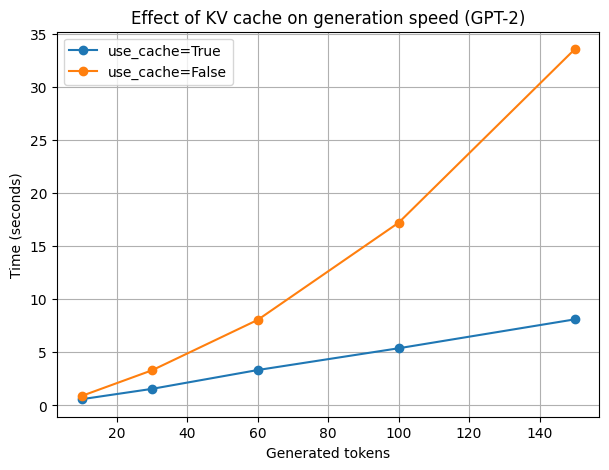

In [7]:
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")
model.eval()


def time_generation(prompt, max_new_tokens, use_cache):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids
    start = time.time()
    with torch.no_grad():
        model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            use_cache=use_cache,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    return time.time() - start


prompt = "Once upon a time"
lengths = [10, 30, 60, 100, 150]
cached_times, uncached_times = [], []

for n in lengths:
    cached_times.append(time_generation(prompt, n, use_cache=True))
    uncached_times.append(time_generation(prompt, n, use_cache=False))
    print(f"tokens={n:3d}  cache=True: {cached_times[-1]:.3f}s   cache=False: {uncached_times[-1]:.3f}s")

plt.figure(figsize=(7, 5))
plt.plot(lengths, cached_times, marker="o", label="use_cache=True")
plt.plot(lengths, uncached_times, marker="o", label="use_cache=False")
plt.xlabel("Generated tokens")
plt.ylabel("Time (seconds)")
plt.title("Effect of KV cache on generation speed (GPT-2)")
plt.legend()
plt.grid(True)
plt.show()

**Note:** the gap grows more visible as `max_new_tokens` increases — on CPU the
raw numbers will be slower overall, but the relative gap between the two lines
should stay clear.